In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [10]:
df = pd.read_csv("retail_sales_dataset.csv")

print("=== DATASET INSPECTION ===")
print("Shape of dataset (Rows, Columns):", df.shape)
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\n--- Duplicate Records ---")
print("Duplicates:", df.duplicated().sum())

df.head()

=== DATASET INSPECTION ===
Shape of dataset (Rows, Columns): (1000, 9)

--- Missing Values Count ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Duplicate Records ---
Duplicates: 0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [11]:
# 1. Convert Date to Datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)
df["Month"] = df["Date"].dt.month_name()
df["DayOfWeek"] = df["Date"].dt.day_name()

# 2. Create Age Group Bins
bins = [17, 25, 35, 50, 70]
labels = ["18-25 (Youth)", "26-35 (Young Adult)", "36-50 (Middle-Aged)", "51+ (Senior)"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("✓ Feature Engineering completed: Age Group & Date columns created!")
df.head(3)

✓ Feature Engineering completed: Age Group & Date columns created!


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,YearMonth,Month,DayOfWeek,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,November,Friday,26-35 (Young Adult)
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,February,Monday,26-35 (Young Adult)
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,January,Friday,36-50 (Middle-Aged)


In [12]:
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

stats_df = pd.DataFrame(
    {
        "Mean": df[num_cols].mean(),
        "Median": df[num_cols].median(),
        "Mode": df[num_cols].mode().iloc[0],
        "Std Dev": df[num_cols].std(),
        "Min": df[num_cols].min(),
        "Max": df[num_cols].max(),
    }
)

print("=== DESCRIPTIVE STATISTICS ===")
stats_df

=== DESCRIPTIVE STATISTICS ===


,Mean,Median,Mode,Std Dev,Min,Max
Age,41.392,42.0,43.0,13.681430,18,64
Quantity,2.514,3.0,4.0,1.132734,1,4
Price per Unit,179.890,50.0,50.0,189.681356,25,500
Total Amount,456.000,135.0,50.0,559.997632,25,2000


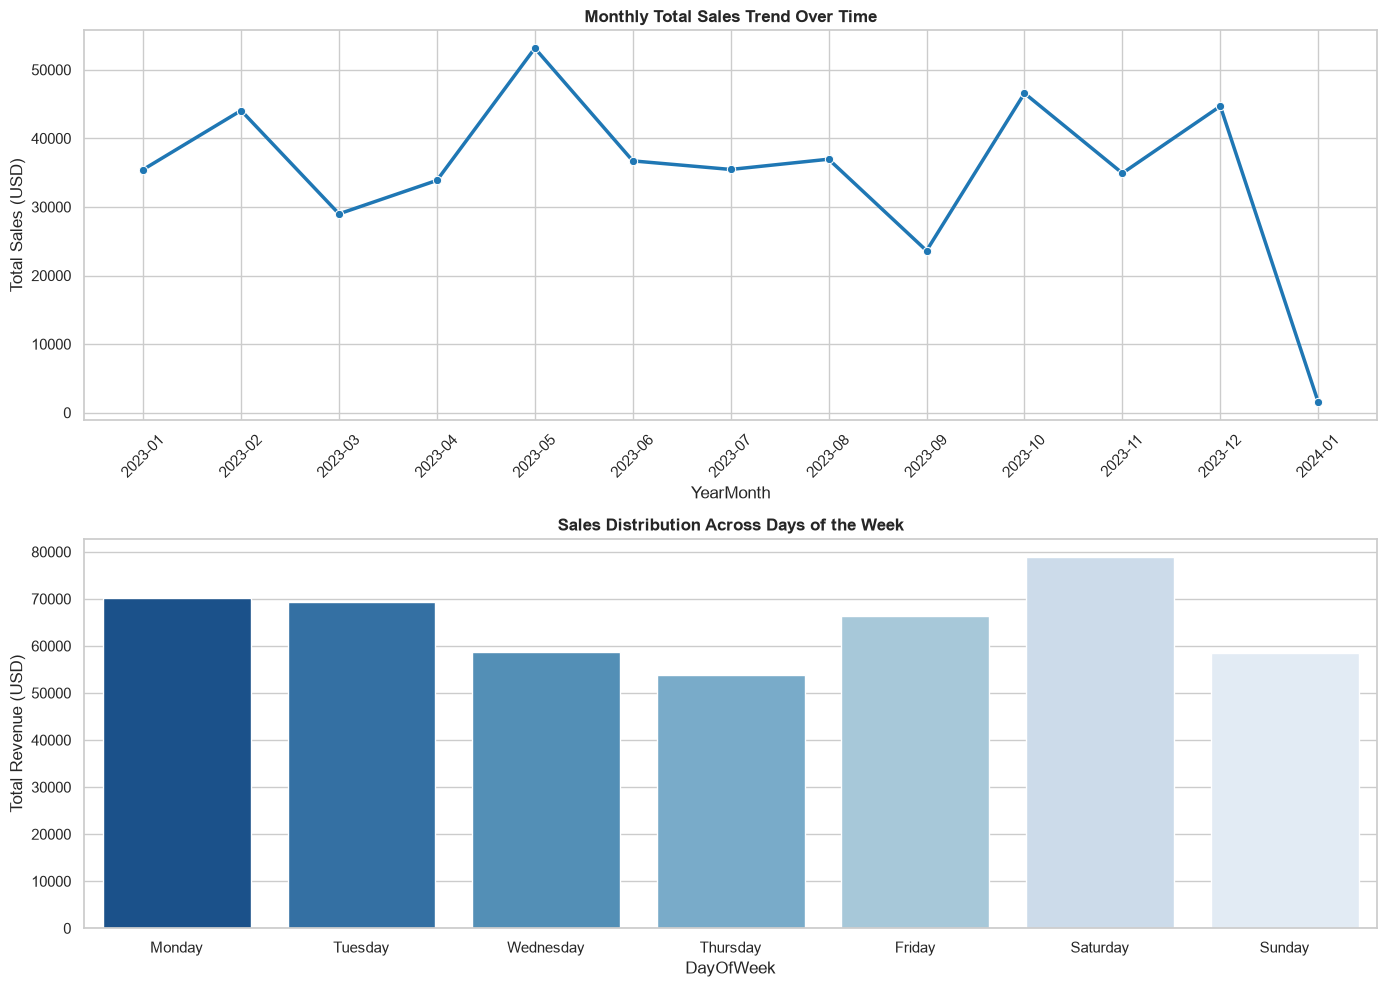

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly Revenue Trend Line Chart
monthly_sales = df.groupby("YearMonth")["Total Amount"].sum()
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    ax=axes[0],
)
axes[0].set_title("Monthly Total Sales Trend Over Time", fontweight="bold")
axes[0].set_ylabel("Total Sales (USD)")
axes[0].tick_params(axis="x", rotation=45)

# Sales by Day of the Week
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_sales = (
    df.groupby("DayOfWeek")["Total Amount"].sum().reindex(days_order)
)
sns.barplot(
    x=day_sales.index,
    y=day_sales.values,
    hue=day_sales.index,
    palette="Blues_r",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Sales Distribution Across Days of the Week", fontweight="bold")
axes[1].set_ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

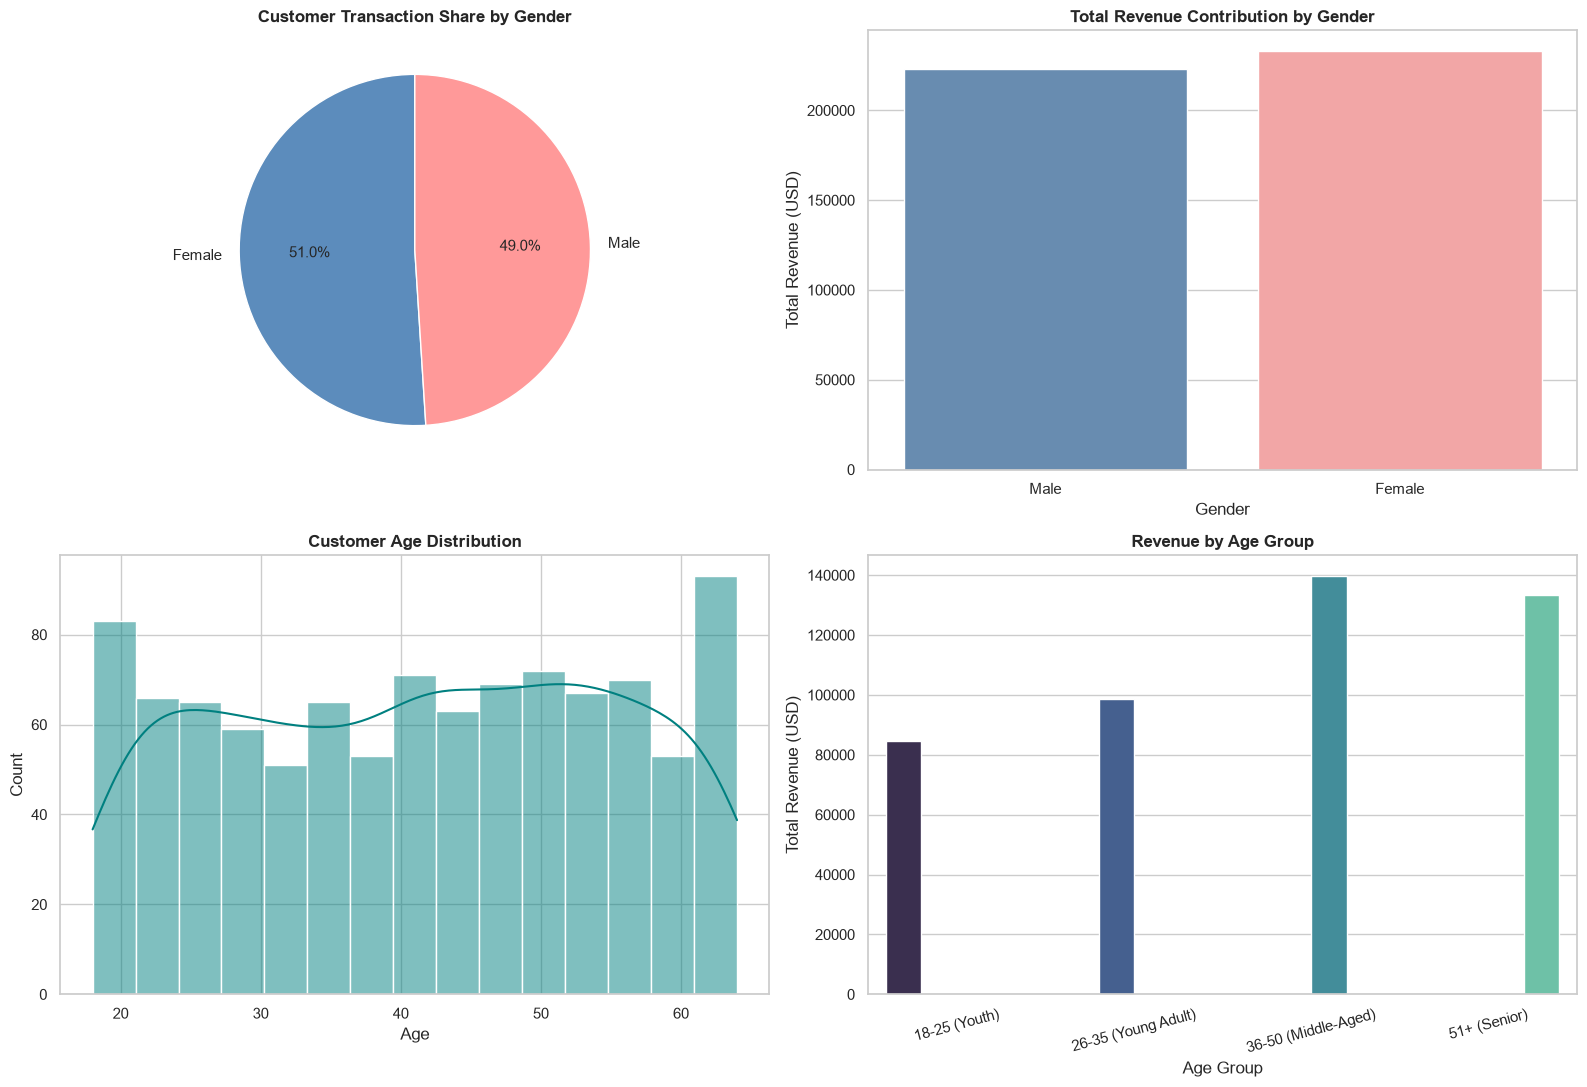

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Gender Distribution (Pie Chart)
gender_counts = df["Gender"].value_counts()
axes[0, 0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#5c8cbc", "#ff9999"],
)
axes[0, 0].set_title("Customer Transaction Share by Gender", fontweight="bold")

# 2. Total Spending by Gender (Bar Chart)
sns.barplot(
    data=df,
    x="Gender",
    y="Total Amount",
    hue="Gender",
    estimator=sum,
    errorbar=None,
    palette=["#5c8cbc", "#ff9999"],
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Total Revenue Contribution by Gender", fontweight="bold")
axes[0, 1].set_ylabel("Total Revenue (USD)")

# 3. Age Distribution (Histogram)
sns.histplot(
    df["Age"], kde=True, bins=15, color="teal", ax=axes[1, 0]
)
axes[1, 0].set_title("Customer Age Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Age")

# 4. Total Sales by Age Group (Bar Chart)
sns.barplot(
    data=df,
    x="Age Group",
    y="Total Amount",
    hue="Age Group",
    estimator=sum,
    errorbar=None,
    palette="mako",
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Revenue by Age Group", fontweight="bold")
axes[1, 1].set_ylabel("Total Revenue (USD)")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

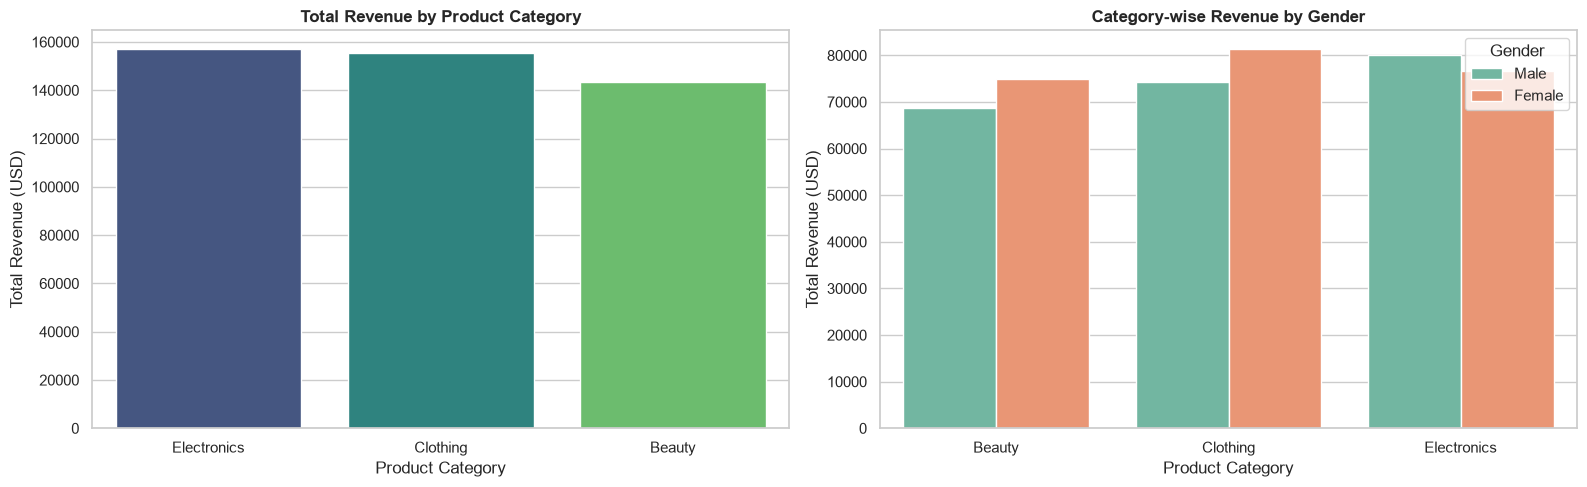

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Category Revenue Breakdown
cat_rev = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)
sns.barplot(
    x=cat_rev.index,
    y=cat_rev.values,
    hue=cat_rev.index,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Total Revenue by Product Category", fontweight="bold")
axes[0].set_ylabel("Total Revenue (USD)")

# 2. Gender Preferences Across Product Categories
sns.barplot(
    data=df,
    x="Product Category",
    y="Total Amount",
    hue="Gender",
    estimator=sum,
    errorbar=None,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Category-wise Revenue by Gender", fontweight="bold")
axes[1].set_ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

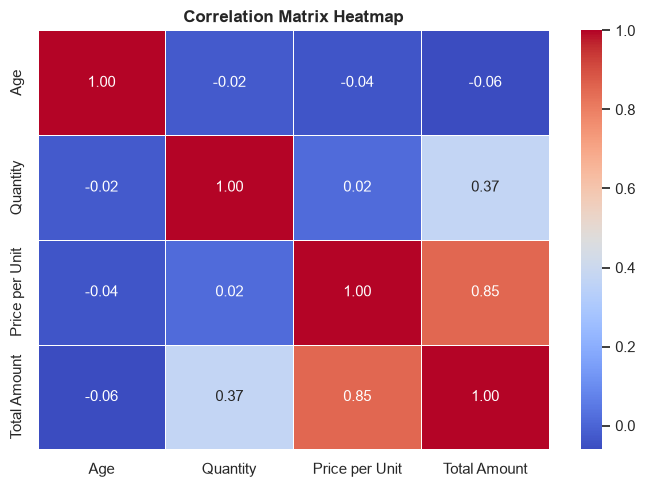

In [16]:
plt.figure(figsize=(7, 5))
corr = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()